In [3]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.processing import WESADDataset

In [4]:
# Load and filter subject S2
loader = WESADDataset('../data/WESAD')
df_raw = loader.load_subject('S2')
df = loader.filter_target_states(df_raw)

# Separate baseline and stress for easy comparison
baseline = df[df['Label'] == 0]
stress   = df[df['Label'] == 1]

print(f"Baseline samples: {len(baseline):,}")
print(f"Stress samples:   {len(stress):,}")

Loading S2 data... This might take a moment.
Baseline samples: 800,800
Stress samples:   430,500


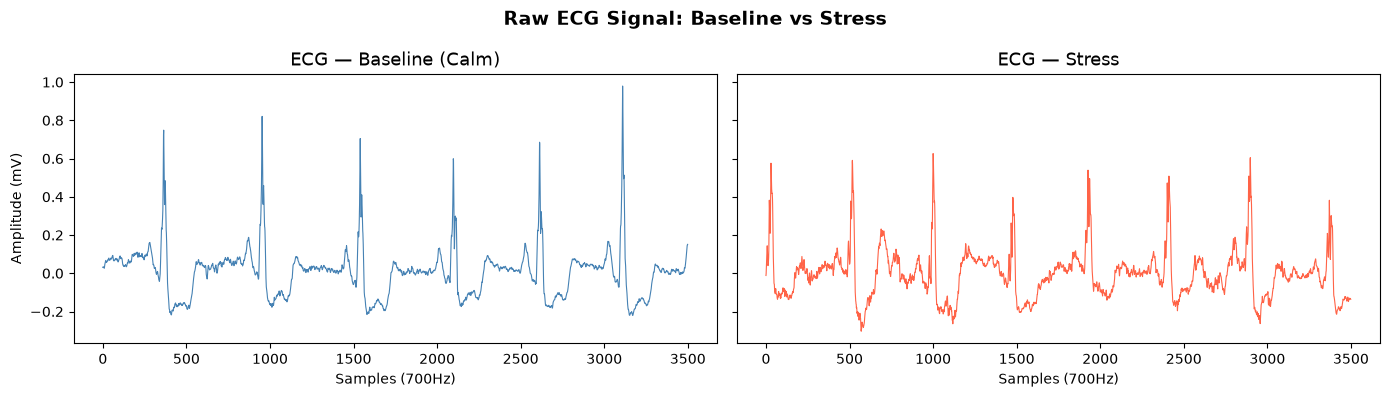

In [6]:
# Take 5 seconds (3500 samples) from each condition
duration = 5 * 700  # 5 seconds at 700Hz

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(baseline['ECG'].values[:duration], color='steelblue', linewidth=0.8)
axes[0].set_title('ECG — Baseline (Calm)', fontsize=13)
axes[0].set_xlabel('Samples (700Hz)')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(stress['ECG'].values[:duration], color='tomato', linewidth=0.8)
axes[1].set_title('ECG — Stress', fontsize=13)
axes[1].set_xlabel('Samples (700Hz)')

plt.suptitle('Raw ECG Signal: Baseline vs Stress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ecg_comparison.png', dpi=150)
plt.show()

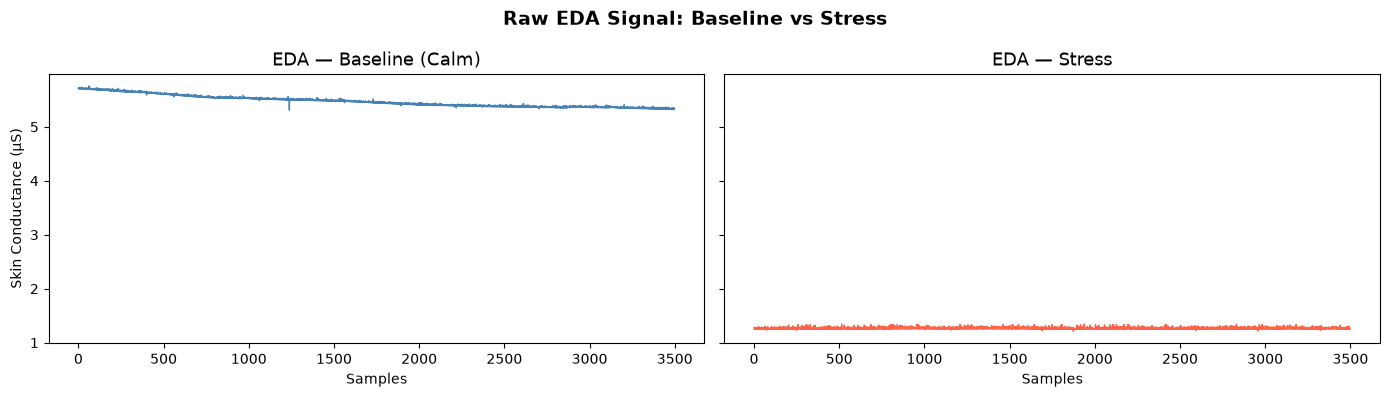

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(baseline['EDA'].values[:duration], color='steelblue', linewidth=1)
axes[0].set_title('EDA — Baseline (Calm)', fontsize=13)
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Skin Conductance (µS)')

axes[1].plot(stress['EDA'].values[:duration], color='tomato', linewidth=1)
axes[1].set_title('EDA — Stress', fontsize=13)
axes[1].set_xlabel('Samples')

plt.suptitle('Raw EDA Signal: Baseline vs Stress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_comparison.png', dpi=150)
plt.show()

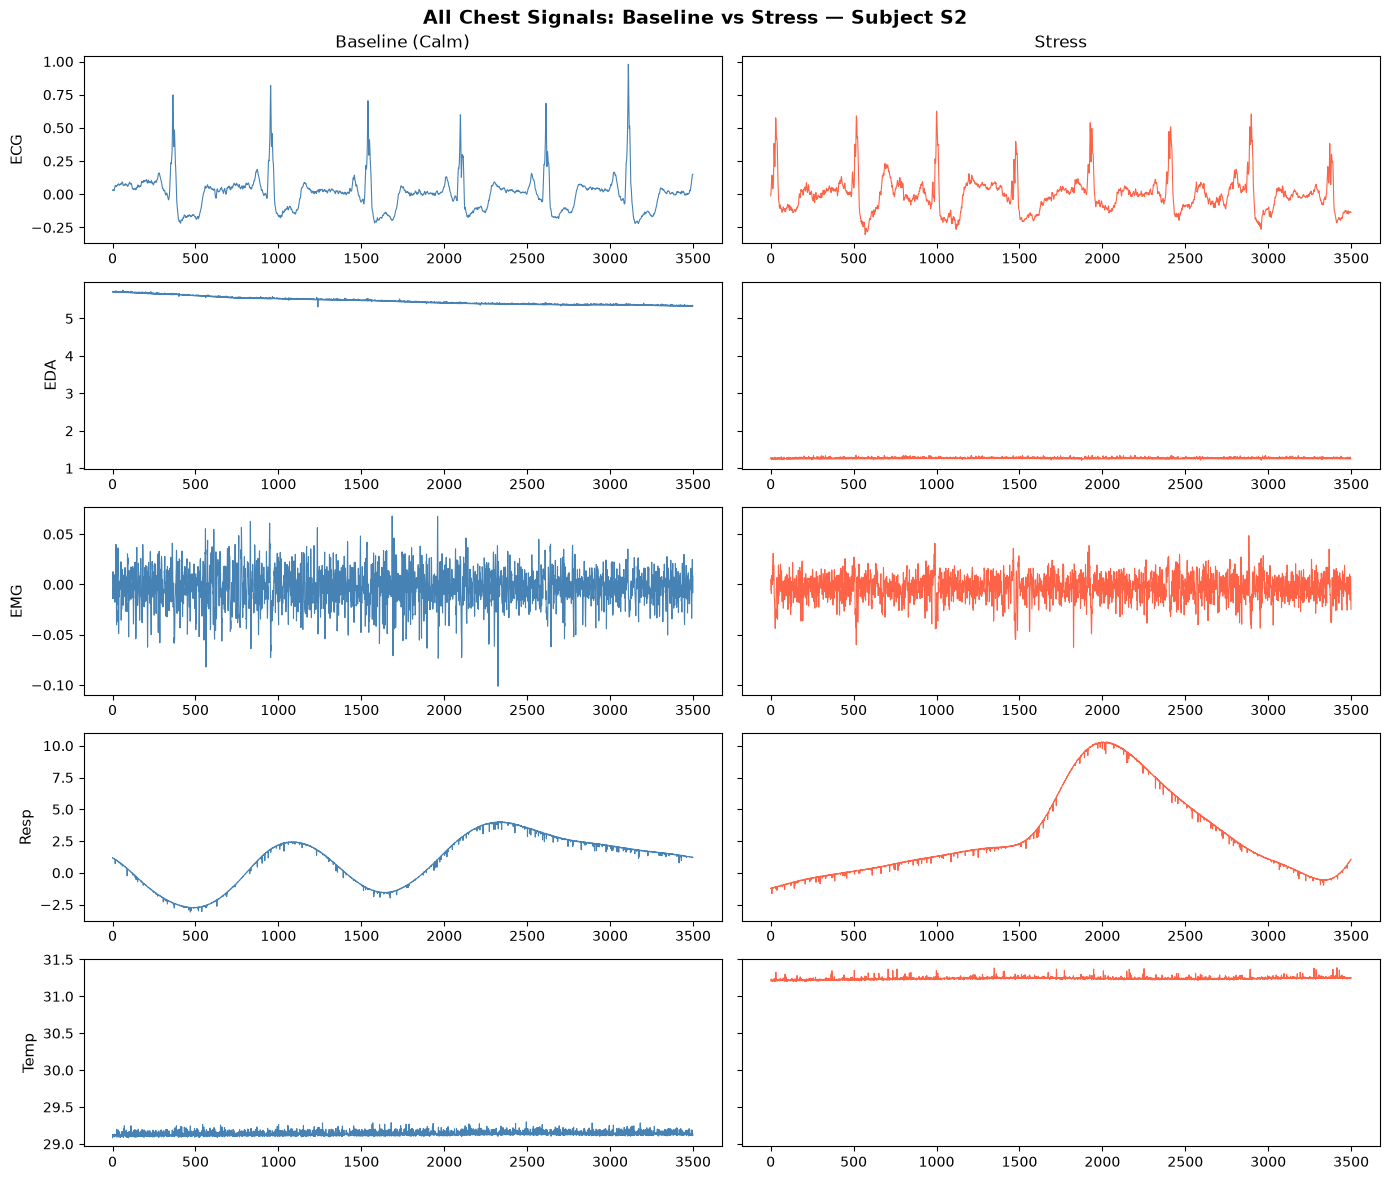

In [8]:
signals = ['ECG', 'EDA', 'EMG', 'Resp', 'Temp']
colors  = {'Baseline': 'steelblue', 'Stress': 'tomato'}

fig, axes = plt.subplots(len(signals), 2, figsize=(14, 12), sharey='row')

for i, signal in enumerate(signals):
    axes[i, 0].plot(baseline[signal].values[:duration],
                    color='steelblue', linewidth=0.8)
    axes[i, 0].set_ylabel(signal, fontsize=11)
    if i == 0:
        axes[i, 0].set_title('Baseline (Calm)', fontsize=12)

    axes[i, 1].plot(stress[signal].values[:duration],
                    color='tomato', linewidth=0.8)
    if i == 0:
        axes[i, 1].set_title('Stress', fontsize=12)

plt.suptitle('All Chest Signals: Baseline vs Stress — Subject S2',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/all_signals_comparison.png', dpi=150)
plt.show()

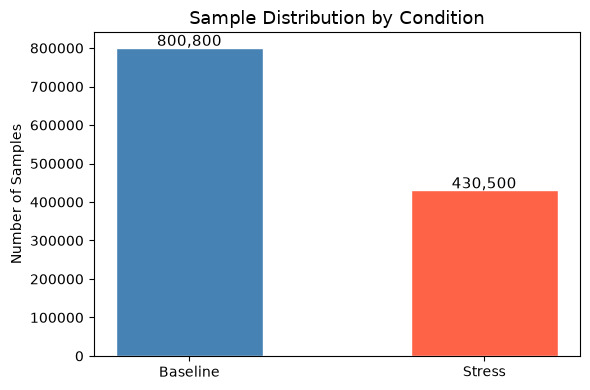

In [9]:
label_map = {0: 'Baseline', 1: 'Stress'}
counts = df['Label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [label_map[i] for i in counts.index],
    counts.values,
    color=['steelblue', 'tomato'],
    edgecolor='white',
    width=0.5
)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5000,
            f'{count:,}', ha='center', fontsize=11)

ax.set_title('Sample Distribution by Condition', fontsize=13)
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('../outputs/label_distribution.png', dpi=150)
plt.show()